In [19]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os

In [20]:
test_path = './dataset/test'
model = YOLO('./model/plate_recognizer.pt')


In [21]:
def sort_boxes_left_to_right(results):
    boxes = results[0].boxes
    sorted_indices = boxes.xyxy[:, 0].argsort()
    sorted_boxes = boxes[sorted_indices]
    return {"boxes": sorted_boxes}

0: 448x448 1 0, 1 1, 2 2s, 1 B, 1 D, 1 P, 1 RO, 432.3ms
Speed: 10.1ms preprocess, 432.3ms inference, 0.3ms postprocess per image at shape (1, 3, 448, 448)

image 1/1 /app/dataset/test/images/27_jpeg_jpg.rf.e5da9dfce1b4eb21024b8e4e87cdc35c.jpg: 448x448 1 0, 1 1, 2 2s, 1 B, 1 D, 1 P, 1 RO, 313.5ms
Speed: 1.9ms preprocess, 313.5ms inference, 0.3ms postprocess per image at shape (1, 3, 448, 448)


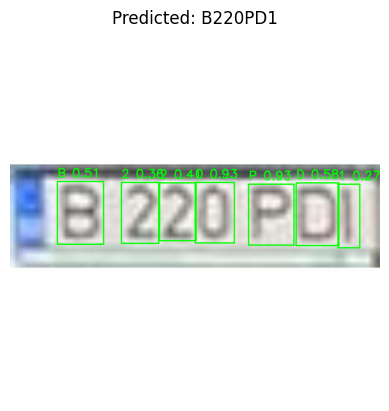


0: 448x448 1 0, 1 9, 1 D, 1 G, 1 K, 1 L, 1 R, 1 RO, 345.1ms
Speed: 3.4ms preprocess, 345.1ms inference, 0.4ms postprocess per image at shape (1, 3, 448, 448)

image 1/1 /app/dataset/test/images/285_jpg.rf.7ad71aac2f587be87ebc646f94242cd7.jpg: 448x448 1 0, 1 9, 1 D, 1 G, 1 K, 1 L, 1 R, 1 RO, 332.9ms
Speed: 3.0ms preprocess, 332.9ms inference, 0.5ms postprocess per image at shape (1, 3, 448, 448)


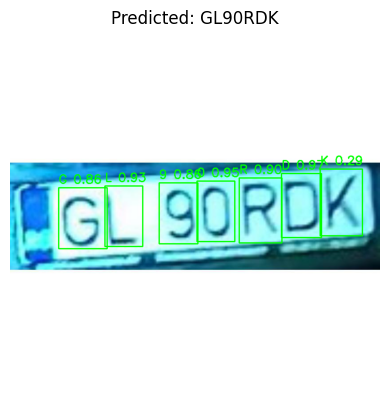


0: 448x448 1 3, 1 4, 1 B, 1 G, 1 M, 1 R, 1 RO, 328.6ms
Speed: 2.2ms preprocess, 328.6ms inference, 0.4ms postprocess per image at shape (1, 3, 448, 448)

image 1/1 /app/dataset/test/images/IMG_5079_JPG_jpg.rf.f53e7393c51435700fa51af89b33a03f.jpg: 448x448 1 3, 1 4, 1 B, 1 G, 1 M, 1 R, 1 RO, 311.7ms
Speed: 2.2ms preprocess, 311.7ms inference, 0.3ms postprocess per image at shape (1, 3, 448, 448)


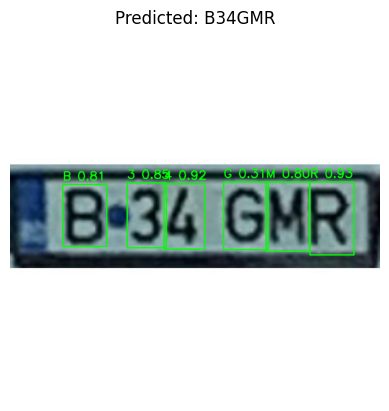

In [24]:
labels = os.listdir(test_path + '/labels')
images = os.listdir(test_path + '/images')

for img in images[:3]:
    img_path = os.path.join(test_path, 'images', img)
    # label_path = os.path.join(test_path, 'labels', img.replace('.jpg', '.txt'))
    image = cv2.imread(img_path)

    results  = model(image)
    plate = ''


    result = sort_boxes_left_to_right(results)
    for box in result["boxes"]:
        x1, y1, x2, y2 = box.xyxy[0]
        conf = box.conf[0]
        cls = box.cls[0]
        char = model.names[int(cls)]
        
        if char == 'RO':
            continue
        plate += char

        cv2.rectangle(image, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
        cv2.putText(image, f'{char} {conf:.2f}', (int(x1), int(y1) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    # Read the image
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Run inference
    results = model(img_path)
    
    # Display results
    plt.imshow(image_rgb)
    plt.title(f'Predicted: {plate}')
    plt.axis('off')
    plt.show()

Ultralytics 8.4.24 🚀 Python-3.12.3 torch-2.10.0+cu128 CPU (AMD Ryzen 7 5700U with Radeon Graphics)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 596.8±142.2 MB/s, size: 26.7 KB)
val: Scanning /app/dataset/test/labels... 27 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 27/27 835.8it/s 0.0s
val: New cache created: /app/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 4.8s/it 9.6s<20.3s
                   all         27        206      0.837       0.92      0.941      0.658
Speed: 1.8ms preprocess, 336.4ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /app/runs/detect/val


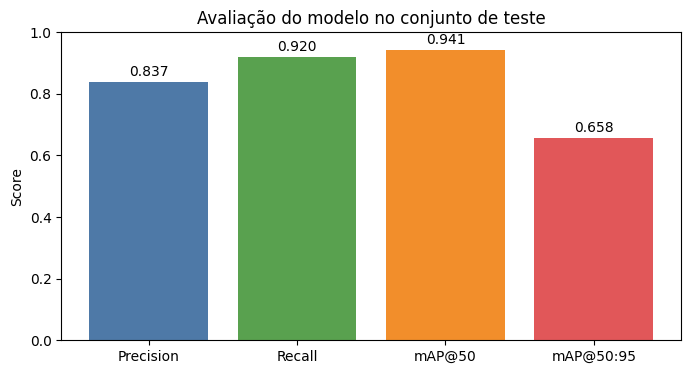

Resumo das métricas:
Precision: 0.8370
Recall: 0.9199
mAP@50: 0.9412
mAP@50:95: 0.6576


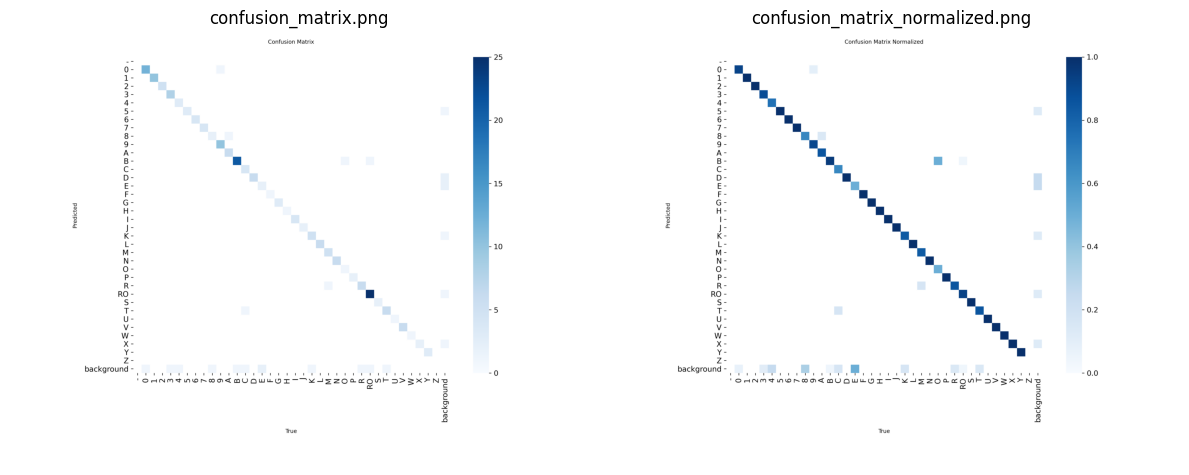

Plots salvos em: /app/runs/detect/val


In [25]:
yaml_candidates = [
    os.path.join(os.path.dirname(test_path), 'data.yaml'),
    os.path.join(os.path.dirname(test_path), 'dataset.yaml'),
    './dataset/data.yaml',
    './dataset/dataset.yaml',
    './data.yaml',
    './dataset.yaml',
]

data_yaml = next((p for p in yaml_candidates if os.path.exists(p)), None)

if data_yaml is None:
    raise FileNotFoundError(
        'Arquivo YAML do dataset não encontrado. '
        'Esperado em algo como ./dataset/data.yaml'
    )

val_metrics = model.val(data=data_yaml, split='test', plots=True, verbose=False)

metrics_dict = val_metrics.results_dict
metric_keys = [
    'metrics/precision(B)',
    'metrics/recall(B)',
    'metrics/mAP50(B)',
    'metrics/mAP50-95(B)',
]
metric_labels = ['Precision', 'Recall', 'mAP@50', 'mAP@50:95']
metric_values = [float(metrics_dict.get(k, 0)) for k in metric_keys]

plt.figure(figsize=(8, 4))
bars = plt.bar(metric_labels, metric_values, color=['#4e79a7', '#59a14f', '#f28e2b', '#e15759'])
plt.ylim(0, 1)
plt.title('Avaliação do modelo no conjunto de teste')
plt.ylabel('Score')

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f'{value:.3f}',
        ha='center'
    )

plt.show()

print('Resumo das métricas:')
for label, value in zip(metric_labels, metric_values):
    print(f'{label}: {value:.4f}')

save_dir = str(val_metrics.save_dir)
plot_files = [
    'PR_curve.png',
    'F1_curve.png',
    'P_curve.png',
    'R_curve.png',
    'confusion_matrix.png',
    'confusion_matrix_normalized.png',
]

available_plots = [
    os.path.join(save_dir, file_name)
    for file_name in plot_files
    if os.path.exists(os.path.join(save_dir, file_name))
]

if available_plots:
    cols = 2
    rows = (len(available_plots) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))

    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1 or cols == 1:
        axes = list(axes)
    else:
        axes = [ax for row in axes for ax in row]

    for ax, plot_path in zip(axes, available_plots):
        plot_img = cv2.imread(plot_path)
        plot_img = cv2.cvtColor(plot_img, cv2.COLOR_BGR2RGB)
        ax.imshow(plot_img)
        ax.set_title(os.path.basename(plot_path))
        ax.axis('off')

    for ax in axes[len(available_plots):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

print(f'Plots salvos em: {save_dir}')